<a href="https://colab.research.google.com/github/Yugansh-Varshney/ANN-Classification-Churn-Prediction-Model/blob/main/ML_Lab2_Penguins_DecisionTree_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Lab 2 — Decision Trees & Random Forests
### Dataset: Palmer Penguins (loaded via seaborn — no external downloads needed)


In this lab you will:
1. Load and explore the dataset
2. Clean missing values and encode categorical features
3. Train a Decision Tree and visualize how it splits
4. Train a Random Forest and compare it to the single tree
5. Check which features matter most



## Section 1: Setup and Load Data

We import the libraries we need and load the **Palmer Penguins** dataset directly from seaborn. It contains measurements of penguins from 3 species (Adelie, Chinstrap, Gentoo) — bill length, bill depth, flipper length, body mass, sex, and which island they were found on.

**Task:** predict the penguin's `species` from its physical measurements.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

sns.set_style("whitegrid")

df = sns.load_dataset("penguins")
print("Shape:", df.shape)
df.head()


Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Section 2: Explore the Raw Data

Before cleaning, check the data types and how many missing values each column has. Missing values here are real (some penguins couldn't be fully measured or sexed in the field) — not placeholder text like `"?"`, so pandas already recognizes them as `NaN`.

In [15]:
df.info()
print()
print("Missing values per column:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


## Section 3: Clean Missing Values

**Task:**
- Drop rows where `species` (our target) is missing, if any.
- For the numeric columns (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`), fill missing values with the **median** of that column.
- For the categorical column `sex`, fill missing values with the **mode** (most frequent value).

Fill in the `# TODO` lines below.

In [16]:
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

# TODO: drop rows where the target column 'species' is missing
df = df.dropna(subset=["species"])

# TODO: fill missing values in numeric_cols with the median of each column
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())  # TODO: replace with the correct fill value

# TODO: fill missing values in 'sex' with the mode of that column
df["sex"] = df["sex"].fillna(df["sex"].mode()[0])  # TODO: replace with the correct fill value

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


## Section 4: Quick Visual Check

A fast plot to see how well the measurements separate the species before we even train a model.

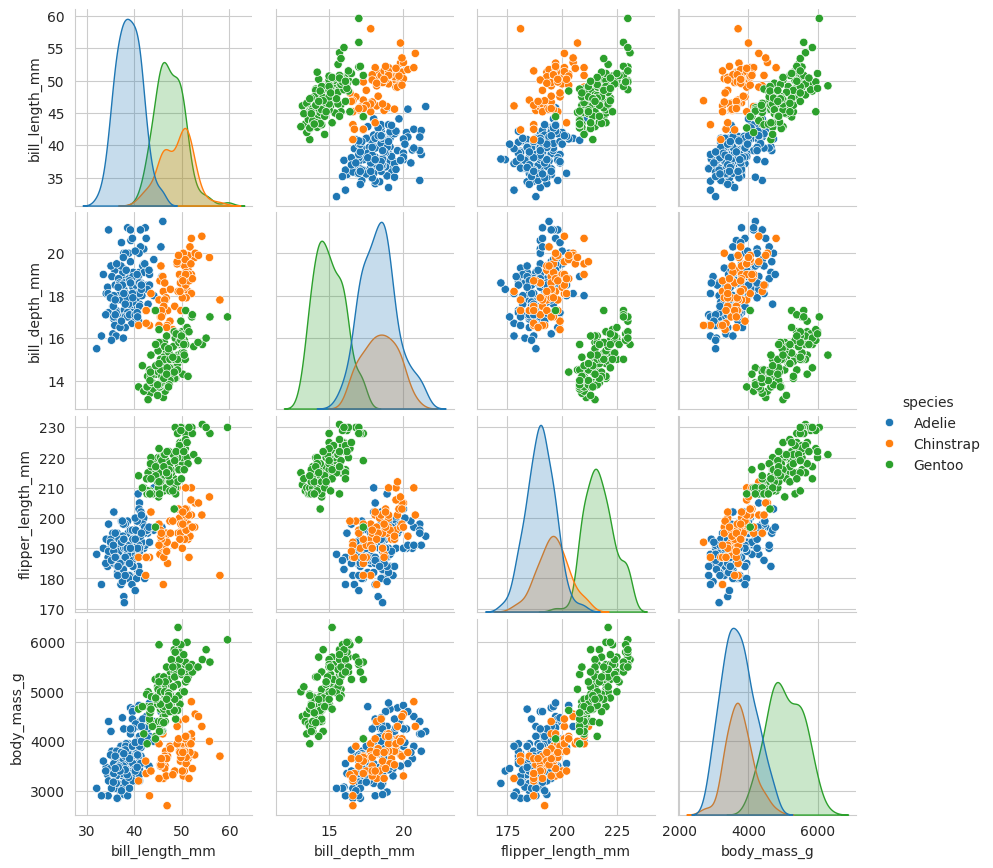

In [17]:
sns.pairplot(df, hue="species", vars=numeric_cols, height=2.2)
plt.show()


## Section 5: Encode Categorical Features

Models need numbers, not text. Use `pd.get_dummies()` to one-hot encode the categorical feature columns (`island`, `sex`) — **not** the target column `species`, which we'll encode separately.

**Task:** build `X` (features) and `y` (target) below.

In [18]:
categorical_feature_cols = ["island", "sex"]

# TODO: one-hot encode categorical_feature_cols from df (excluding 'species'), drop_first=True
X = pd.get_dummies(df.drop(columns=["species"]), columns=categorical_feature_cols, drop_first=True)

# TODO: encode y as the species labels (as numeric codes)
y = df["species"].astype("category").cat.codes
species_names = df["species"].astype("category").cat.categories.tolist()

print("Feature matrix shape:", X.shape)
print("Classes:", species_names)


Feature matrix shape: (344, 7)
Classes: ['Adelie', 'Chinstrap', 'Gentoo']


## Section 6: Train/Test Split

We hold out 20% of the data to test the model on penguins it never saw during training. `stratify=y` keeps the species proportions consistent between train and test sets.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (275, 7)
Test shape: (69, 7)


## Section 7: Train a Decision Tree

A Decision Tree splits the data into branches based on feature values, choosing splits that best separate the classes (using Gini impurity by default).

**Task:** create a `DecisionTreeClassifier` with `max_depth=3` and fit it on the training data.

In [20]:
# TODO: create a DecisionTreeClassifier with max_depth=3, random_state=42
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# TODO: fit it on X_train, y_train
tree_model.fit(X_train, y_train)

print("Tree trained.")


Tree trained.


## Section 8: Visualize the Tree

Run this to see the actual splits the tree learned. Trace a path from the root to a leaf — does the logic match what you saw in the pairplot earlier?

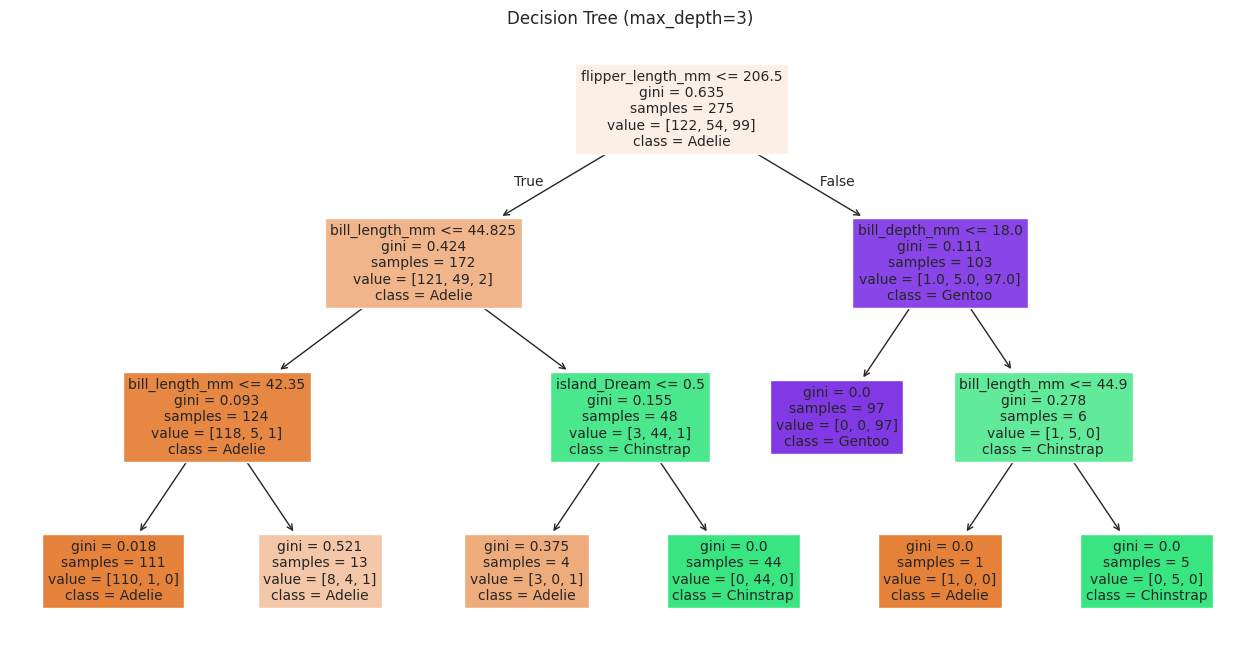

In [21]:
plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns, class_names=species_names, filled=True, fontsize=10)
plt.title("Decision Tree (max_depth=3)")
plt.show()


## Section 9: Evaluate the Decision Tree

**Task:** get predictions on the test set and print the accuracy and classification report.

In [22]:
# TODO: get predictions on X_test
tree_preds = tree_model.predict(X_test)

# TODO: print accuracy_score comparing y_test and tree_preds
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_preds))
print()
print(classification_report(y_test, tree_preds, target_names=species_names))


Decision Tree Accuracy: 0.9710144927536232

              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        30
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       0.96      1.00      0.98        25

    accuracy                           0.97        69
   macro avg       0.98      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69



## Section 10: Why Not Just Use a Very Deep Tree?

An unconstrained tree keeps splitting until every leaf is pure — even down to single penguins — which means it starts memorizing noise instead of general patterns. This is **overfitting**. The plot below shows train vs test accuracy as depth increases.

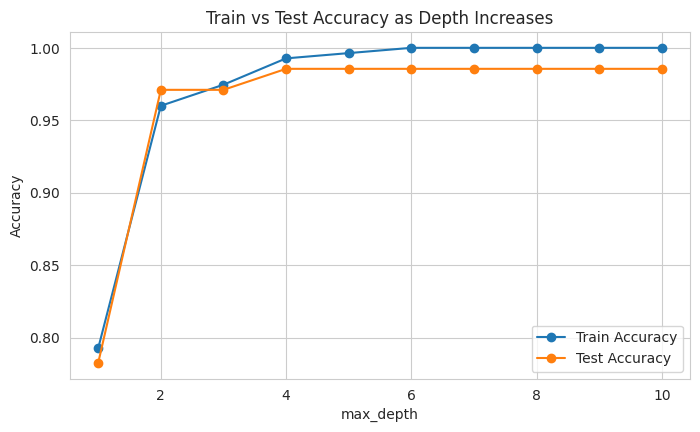

In [23]:
depths = range(1, 11)
train_acc, test_acc = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 4.5))
plt.plot(depths, train_acc, marker="o", label="Train Accuracy")
plt.plot(depths, test_acc, marker="o", label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy as Depth Increases")
plt.legend()
plt.show()


## Section 11: Train a Random Forest

A Random Forest trains many decision trees, each on a random subset of the data and features, then averages their predictions. This averaging usually generalizes better than any single tree.

**Task:** create a `RandomForestClassifier` with `n_estimators=200`, fit it, and evaluate it the same way as the tree.

In [24]:
# TODO: create a RandomForestClassifier with n_estimators=200, random_state=42
forest_model = RandomForestClassifier(n_estimators=200, random_state=42)

# TODO: fit it on the training data
forest_model.fit(X_train, y_train)

# TODO: predict on X_test
forest_preds = forest_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, forest_preds))
print()
print(classification_report(y_test, forest_preds, target_names=species_names))


Random Forest Accuracy: 1.0

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



## Section 12: Compare Confusion Matrices

Side by side, see exactly which species each model confuses (if any).

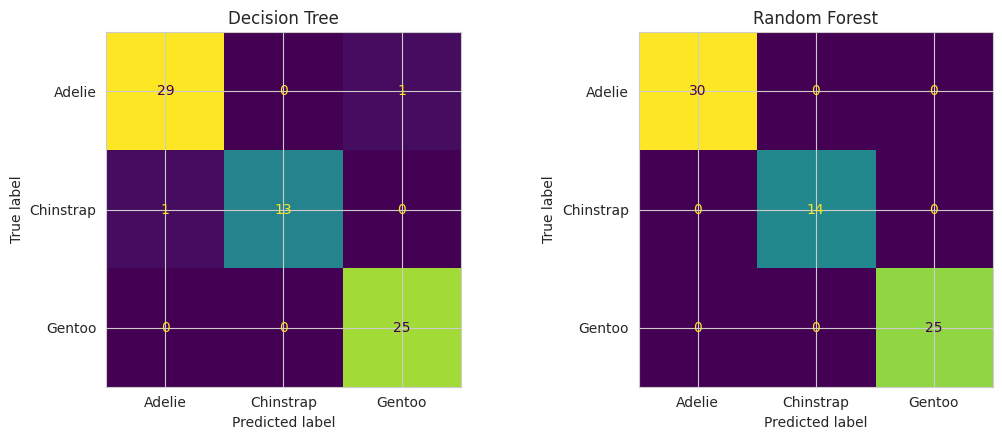

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, tree_preds, display_labels=species_names, ax=axes[0], colorbar=False)
axes[0].set_title("Decision Tree")
ConfusionMatrixDisplay.from_predictions(y_test, forest_preds, display_labels=species_names, ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.show()


## Section 13: Which Features Matter Most?

**Task:** extract `forest_model.feature_importances_`, put it in a pandas Series indexed by `X.columns`, sort descending, and plot the top features as a horizontal bar chart.

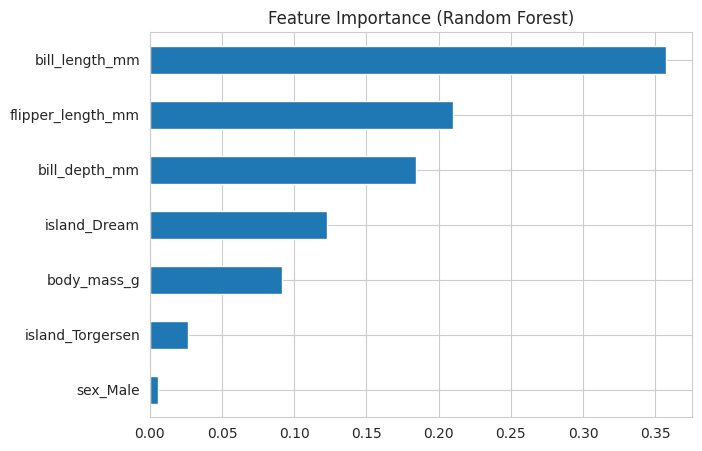

In [26]:
# TODO: build a pandas Series of feature_importances_ indexed by X.columns
importances = pd.Series(forest_model.feature_importances_, index=X.columns)

# TODO: sort descending and take the top values
top_features = importances.sort_values(ascending=False)

plt.figure(figsize=(7, 5))
top_features.plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


## Section 14: If You Finish Early

1. Change `max_depth` in Section 7 to `None` (unlimited) — does the tree in Section 8 become unreadable? What happens to test accuracy?
2. In Section 11, try `max_features="sqrt"` on the Random Forest — does accuracy change?
3. Look at the confusion matrices in Section 12 — is there one species the models mix up more than others? Check the pairplot in Section 4 for a possible reason why.